# Статистика, DS-поток
## Марафон-домашка SM.9, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.



**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.





In [499]:
# Bot check

# HW_ID: ds_sm9
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1266]:
import numpy as np
import scipy.stats as sps
from tqdm.notebook import tqdm
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import RegressorMixin

from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor 

import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.regression.linear_model import RegressionResultsWrapper

from typing import Optional, Tuple
RANDOM_STATE = 42

---
### Задача 1. 

Пусть $Y_1, ..., Y_n$ &mdash; выборка из распределения $\mathcal{N}(\theta, \sigma^2)$, причем $\theta$ и $\sigma$ неизвестны. На семинаре были построены интервалы:
* доверительный интервал для $\theta$,
* предсказательный интервал для нового наблюдения $Y_0$.

Визуализируйте эти интервалы в зависимости от размера выборки (от 1 до 100) аналогично домашнему заданию 3. На график нанесите точки выборки.

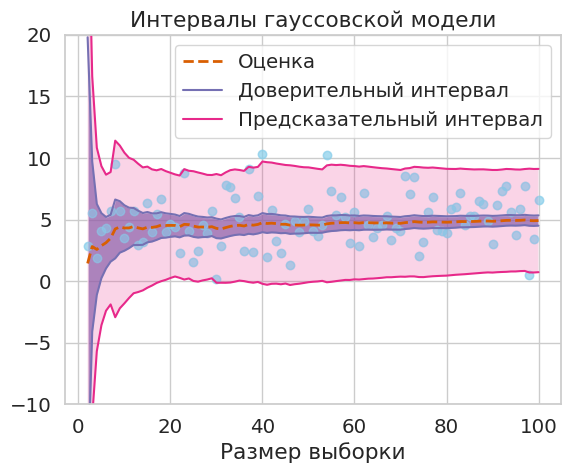

In [1267]:
#Доверительный интервал
sns.set_style('whitegrid')

theta = 5
scale = 2
alpha = 0.05
n_max = 100
n_range = np.arange(2, n_max + 1)
y = sps.norm(loc=theta, scale=scale).rvs(n_max - 1)

theta_hat = np.cumsum(y) / n_range
y_sq_bar = np.cumsum(y ** 2) / (n_range - 1)
y_bar_sq = theta_hat ** 2 * n_range / (n_range - 1)

scale_hat = np.sqrt(y_sq_bar - y_bar_sq)
t = sps.t(n_range - 1).ppf(1 - alpha / 2)
left = theta_hat - t * scale_hat / np.sqrt(n_range)
right = theta_hat + t * scale_hat / np.sqrt(n_range)

plt.plot(n_range, theta_hat, linestyle='--', color='#d95f02', lw=2, label='Оценка')
plt.plot(n_range, left, color='#7570b3', label='Доверительный интервал')
plt.plot(n_range, right, color='#7570b3')
plt.fill_between(n_range, left, right, alpha=0.7)
plt.scatter(n_range, y, color='skyblue', alpha=0.5)
plt.ylim(3, 7)
plt.title(r'Доверительный интервал для $\theta$')

#Предсказательный интервал
theta_hat = np.cumsum(y) / n_range
y_sq_bar = np.cumsum(y ** 2) / (n_range - 1)
y_bar_sq = theta_hat ** 2 * n_range / (n_range - 1)

scale_hat = np.sqrt(y_sq_bar - y_bar_sq)
t = sps.t(n_range - 1).ppf(1 - alpha / 2)
left = theta_hat - t * scale_hat * np.sqrt(1 / n_range + 1)
right = theta_hat + t * scale_hat * np.sqrt(1 / n_range + 1)

plt.plot(n_range, left, color='#e7298a', label='Предсказательный интервал')
plt.plot(n_range, right, color='#e7298a')
plt.fill_between(n_range, left, right, alpha=0.2)
plt.scatter(n_range, y, color='skyblue', alpha=0.4)
plt.title(r'Интервалы гауссовской модели')
plt.xlabel('Размер выборки')
plt.ylim(-10, 20)
plt.legend()
plt.show()

Повторите эксперимент несколько раз и оцените долю покрытия для предсказательного интервала.

In [1268]:
m = 10000
p = np.zeros(shape=(m, n_max - 1))
l = np.zeros(shape=(m, n_max - 1))
t = sps.t(n_range - 1).ppf(1 - alpha / 2)
for i in tqdm(range(m)):
    
    y = sps.norm(loc=theta, scale=scale).rvs(n_max - 1)
    
    theta_hat = np.cumsum(y) / n_range
    y_sq_bar = np.cumsum(y ** 2) / (n_range - 1)
    y_bar_sq = theta_hat ** 2 * n_range / (n_range - 1)
    
    scale_hat = np.sqrt(y_sq_bar - y_bar_sq)
    left = theta_hat - t * scale_hat * np.sqrt(1 / n_range + 1)
    right = theta_hat + t * scale_hat * np.sqrt(1 / n_range + 1)

    j = 0 
    while j < len(left):
        left_i = left[j]
        right_i = right[j]
        p[i, j] = np.mean((y >= left_i) * (y <= right_i))
        l[i, j] = right_i - left_i
        j += 1

  0%|          | 0/10000 [00:00<?, ?it/s]

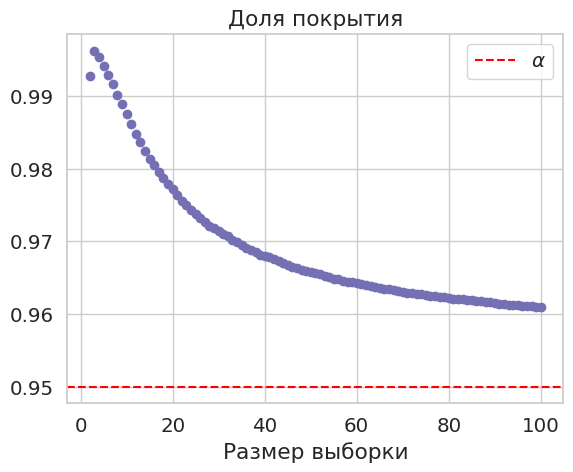

In [1269]:
plt.scatter(n_range, p.mean(axis=0))
plt.axhline(1 - alpha, color='r', linestyle='--', label=r'$\alpha$')
plt.title('Доля покрытия')
plt.xlabel('Размер выборки')
plt.legend()
plt.show()

Сделайте вывод. Поясните подробно, как меняется длина интервалов при увеличении выборки.

Видим, что предсказательный доверитльный интервал сильно шире, чем доверительный для параметра. С ростомы выборки доля покрытия убывает, но не ниже 0.95

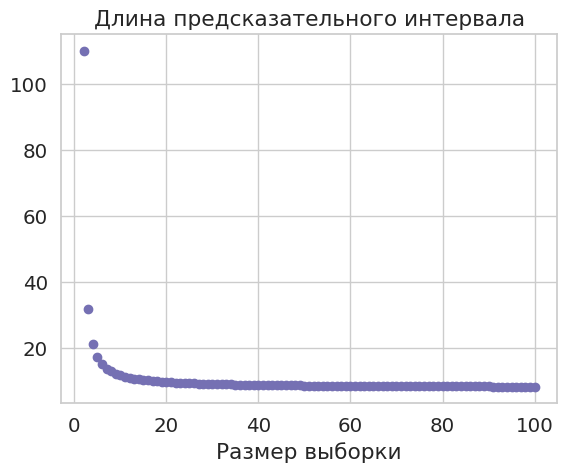

In [1270]:
plt.scatter(n_range, l.mean(axis=0))
plt.title('Длина предсказательного интервала')
plt.xlabel('Размер выборки')
plt.show()

Длина доверительного интервала с ростом выборки умееньшается, потому что, скажем, единичное наблюдение сильно более нестабильное, чем 100 наблюдений. Интервал это учитывает и сужается

---
### Задача 2. 

Рассмотрим датасет [NYC Taxi Trip Duration](https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data). Этот датасет содержит данные о поездках жёлтых такси в Нью-Йорке за 2016 год. Его собрала компания NYC Taxi and Limousine Commission (TLC) — официальный регулятор такси в Нью-Йорке. Информация включает время и место начала и окончания поездки, её длительность, расстояние, количество пассажиров, тип поставщика и другие характеристики.

Изначально данные использовались в конкурсе на Kaggle, где участникам нужно было создать модель для прогнозирования времени поездки. Набор данных полезен для анализа городского трафика, регрессионных задач, прогнозирования спроса на такси, оценки загруженности районов, моделирования пробок и анализа транспортной инфраструктуры.

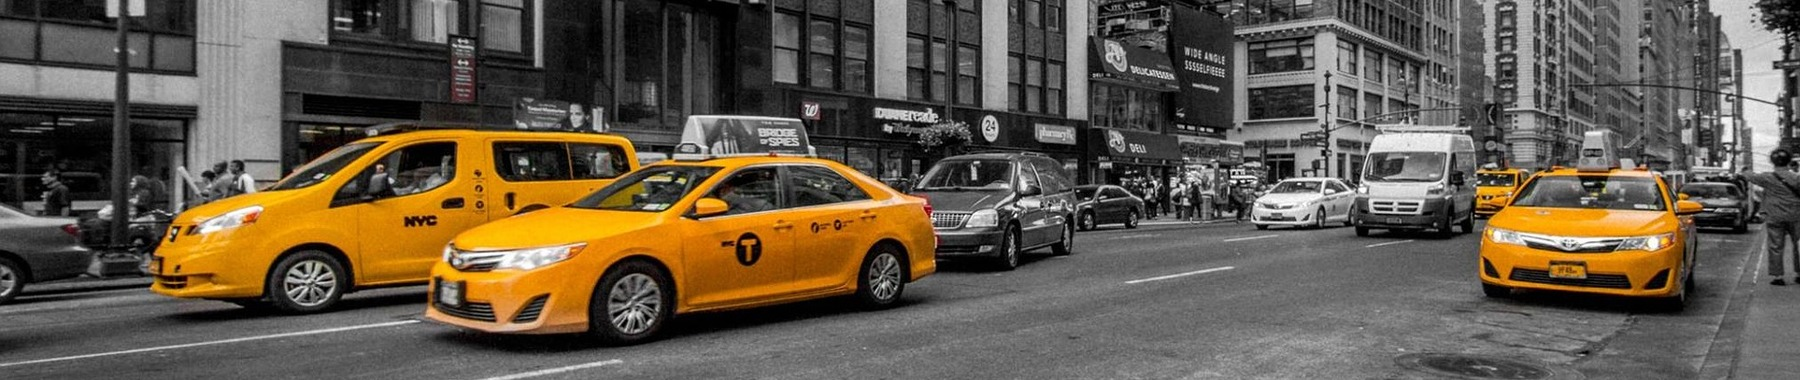

**Описание признаков**

* `id` — уникальный идентификатор поездки;  
* `vendor_id` — идентификатор поставщика (`1` или `2`, разные операторы такси);  
* `pickup_datetime` — дата и время начала поездки;  
* `dropoff_datetime` — дата и время завершения поездки;  
* `passenger_count` — количество пассажиров в машине;  
* `pickup_longitude`, `pickup_latitude` — координаты точки посадки пассажира;  
* `dropoff_longitude`, `dropoff_latitude` — координаты точки высадки пассажира;  
* `store_and_fwd_flag` — индикатор, сохранялись ли данные поездки локально перед передачей (`Y`/`N`);  
* `trip_duration` — длительность поездки в секундах (**таргет**).

**Задача**

Построить модель регрессии для прогнозирования длительности поездки по признакам, доступным в начале поездки — например, по времени, координатам и числу пассажиров.

Также практический интерес представляет построение предсказательных интервалов, позволяющих оценить диапазон возможной продолжительности поездки для конкретного маршрута. Например, *"Поездка от Центрального парка до аэропорта Ла-Гуардия в 8 утра обычно длится от 23 до 27 минут."*


---

Скачаем данные и посмотрим на них

In [1271]:
df = pd.read_csv("train.csv", parse_dates=["pickup_datetime", "dropoff_datetime"])
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [1272]:
df.shape

(1458644, 11)

Данных довольно много. Для отладки кода рекомендуем работать с небольшой подвыборкой

In [1273]:
# Убери этот код для финального прогона
# df = df.sample(n=20_000, random_state=RANDOM_STATE).reset_index(drop=True)

**1.** **Генерация признаков исходя из постановки задачи**

Некоторые преобразования признаков можно совершить только на основе знаний предметной сферы вне зависимости от  конкретных данных. Для удобства в рамках исследования эти преобразования можно сделать сразу на всех данных без деления на трейн и тест.

Переведем секунды в минуты, с ними нам привычнее иметь дело, когда речь идет о поездках на такси по городу

In [1274]:
df["trip_duration_min"] = df["trip_duration"] / 60.0

Также полезно будет учитывать расстояние между точками посадки и высадки пассажиров. Можно использовать евклидово расстояние между координатами (`pickup_longitude`, `pickup_latitude`) и (`dropoff_longitude`, `dropoff_latitude`). Однако, это расстояние не учитывает кривизну Земли. В рамках одного города это может быть не существенно, тем не менее, для наглядности рассмотрим, как вычислить реальное расстояние в километрах.

> Расстояние между двумя точками на поверхности Земли, заданными широтой и долготой можно вычислить по формуле Haversine дугового расстояния
> 
> $$
d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\varphi}{2}\right) + \cos \varphi_1 \cos \varphi_2 \sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)
$$
> 
> где:  
> - $\varphi_1, \varphi_2$ — широта точек (в радианах),  
> - $\lambda_1, \lambda_2$ — долгота точек (в радианах),  
> - $R = 6371$ км — радиус Земли,  
> - $\Delta\varphi = \varphi_2 - \varphi_1$,
> - $\Delta\lambda = \lambda_2 - \lambda_1$.



In [1275]:
from typing import Union
Coordinate = Union[float, np.ndarray, pd.Series]

def haversine(lat1: Coordinate, lon1: Coordinate, lat2: Coordinate, lon2: Coordinate) -> np.ndarray:
    """
    Вычисляет расстояние между двумя точками на Земле по формуле гаверсина.

    Параметры
    ----------
    lat1: Широта первой точки в градусах.
    lon1: Долгота первой точки в градусах.
    lat2: Широта второй точки в градусах.
    lon2: Долгота второй точки в градусах.

    Возвращает
    -------
    np.ndarray
        Расстояние между точками в километрах.
    """
    R = 6371.0  # Средний радиус Земли в километрах

    # Преобразование градусов в радианы для вычислений
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    # Основная формула Гаверсина
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    # Использование arctan2 для большей точности
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [1276]:
df["distance_km"] = haversine(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"],
)

Посчитаем среднюю скорость в километрах в час. *Заметьте, что она определяется на основе таргета, ее нельзя будет использовать как признак.*

In [1277]:
df["speed"] = df["distance_km"] / (df["trip_duration_min"] / 60)

Построим признаки на основе даты, вы можете по своему усмотрению использовать их или не использовать

In [1278]:
# День недели (0 = понедельник)
df["weekday"] = df["pickup_datetime"].dt.weekday
# Выходные
df["is_weekend"] = (df["weekday"] >= 5).astype(int)
# Часы
df["hour"] = df["pickup_datetime"].dt.hour
# Утренний час-пик
df["is_peak_morning"] = df["hour"].between(7, 10).astype(bool)
# Вечерний час-пик
df["is_peak_evening"] = df["hour"].between(16, 20).astype(bool)

Можем добавить какую-то нелинейность. Например, вы можете взять примеры ниже или же предложить свои

In [1279]:
df['is_peak'] = (df["is_peak_morning"] + df["is_peak_evening"]).astype(int)
# некоторые признаки можно убрать
df["dist_peak"] = df["distance_km"] * df["is_peak"]
df["dist_weekend"] = df["distance_km"] * df["is_weekend"]
df["dist2"] = df["distance_km"] ** 2
df["log_dist"] = np.log1p(df["distance_km"])

# придумайте свои признаки исходя из постановки задачи
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day

Разделите данные на обучающую и тестовую части

In [1280]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'trip_duration_min', 'distance_km', 'speed', 'weekday',
       'is_weekend', 'hour', 'is_peak_morning', 'is_peak_evening', 'is_peak',
       'dist_peak', 'dist_weekend', 'dist2', 'log_dist', 'month', 'day'],
      dtype='object')

In [1281]:
X = df.drop(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 
             'store_and_fwd_flag', 'trip_duration', 'trip_duration_min', 
             'speed', 'is_peak_morning', 'is_peak_evening'], axis=1)
y = df['trip_duration_min']

In [1282]:
X_test

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,log_dist,passenger_count_1,passenger_count_2,passenger_count_3,passenger_count_4,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
10650,-73.985687,40.727005,-73.981407,40.758480,3.518394,1.508157,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2041,-73.980110,40.759743,-73.784439,40.643356,20.965764,3.089485,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8668,-73.962166,40.779205,-73.968445,40.761395,2.049845,1.115091,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1114,-73.993919,40.746380,-73.850960,40.733299,12.131886,2.575043,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13902,-73.778267,40.646801,-73.762108,40.606411,4.693644,1.739350,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4073,-73.938187,40.792316,-73.918625,40.839001,5.445826,1.863433,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7442,-73.991592,40.729462,-73.979507,40.720280,1.442060,0.892842,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9999,-73.977074,40.750187,-74.014824,40.709381,5.541338,1.878142,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1870,-74.003822,40.747990,-73.982300,40.745495,1.834189,1.041756,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [1283]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

**2.** **Фильтрация данных**

Посмотрим на распределение данных. 
* Постройте гистограммы для длительности поездки и для расстояния.
* Постройте scatterplot для этих двух признаков (указывайте малое значение непрозрачности `alpha` для информативности графика, на полных данных не более 0.01).

Что можно сказать про эти признаки?

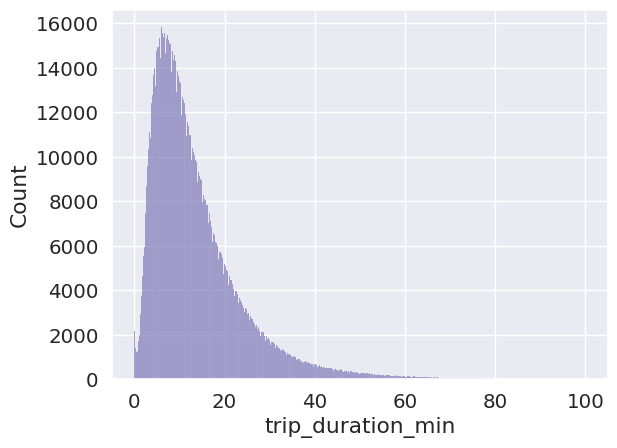

In [1284]:
sns.set_style('darkgrid')
#Уберём пока выбросы
sns.histplot(y_train[y_train <= 100])
plt.show()

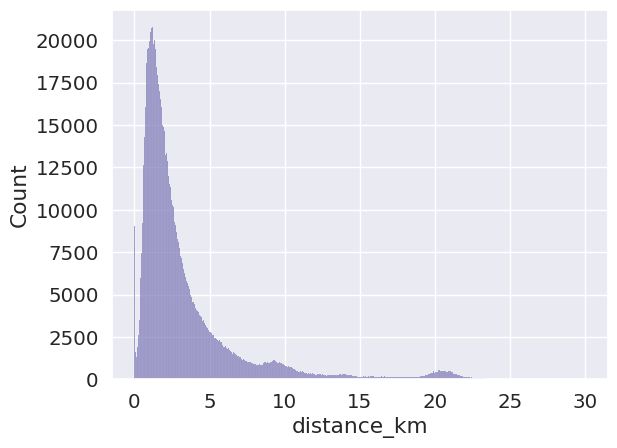

In [1285]:
sns.histplot(X_train.loc[X_train['distance_km'] <= 30, 'distance_km'])
plt.show()

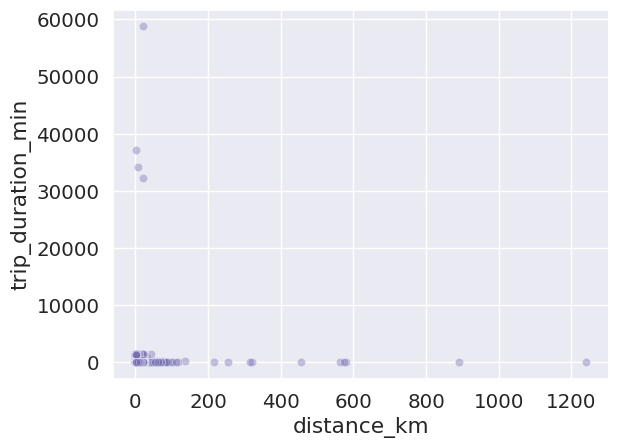

In [1286]:
sns.scatterplot(x=X_train['distance_km'], y=y_train, alpha=0.4)
plt.show()

На графиках явно заметны выбросы, удалите их и снова постройте scatterplot. Сколько процентов данных пришлось удалить?

In [1287]:
column = 'distance_km'
data = X_train[column]
q1 = np.quantile(data, 0.25)
q3 = np.quantile(data, 0.75)
iqr = q3 - q1
mask = (data >= q1 - 1.5 * iqr) & (data <= 20)

print(f"Из столбца '{column}' удалено {100 - mask.sum() / len(data) * 100:.2f}% данных")
X_train_out = X_train[mask]
y_train_out = y_train[mask]

data = y_train_out
q1 = np.quantile(data, 0.25)
q3 = np.quantile(data, 0.75)
iqr = q3 - q1
mask = (data >= q1 - 1.5 * iqr) & (data <= q3 + 1.5 * iqr)

print(f"Из столбца '{y.name}' удалено {100 - mask.sum() / len(data) * 100:.2f}% данных")
X_train_out = X_train_out[mask]
y_train_out = y_train_out[mask]

Из столбца 'distance_km' удалено 1.63% данных
Из столбца 'trip_duration_min' удалено 4.31% данных


Верхнюю границу расстояний почистил на глаз

Если вы немного пожалели данные при удалении выбросов выше, на обновленном графике вы увидите еще сгусток выбросов. Возможно, это связано с поездками в определенную точку Нью-Йорка. Такие поездки можно обрабатывать как-то отдельно, сейчас же для простоты сосредоточимся только на обработке основного набора данных.

При необходимости удалите оставшиеся выбросы и снова постройте scatterplot. В результате должны остаться поездки до 15-18 км и до 60-80 минут. Сколько процентов данных пришлось удалить?

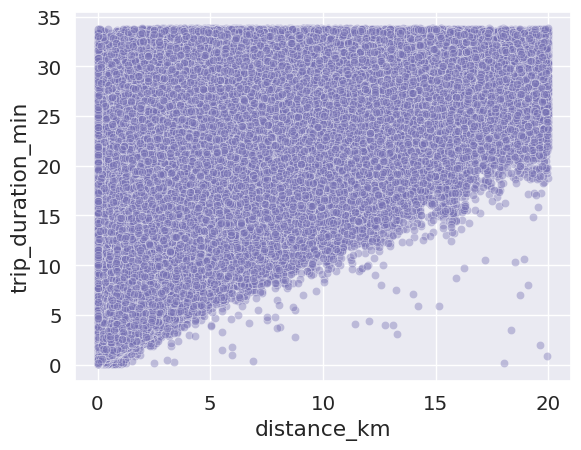

In [1288]:
sns.scatterplot(x=X_train_out['distance_km'], y=y_train_out, alpha=0.4)
plt.show()

Обратите внимание на короткие поездки. На графике можно заметить некоторое количество длительных поездок с нулевым расстоянием. Очевидно, в них что-то пошло не так. Удалите эти точки и снова постройте scatterplot. Все ли теперь хорошо?

In [1289]:
mask = X_train_out['distance_km'] > 0
X_train_out = X_train_out.loc[mask, :]
y_train_out = y_train_out[mask]

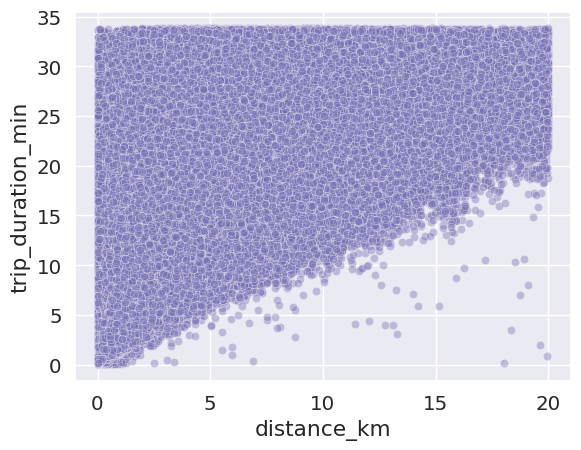

In [1290]:
sns.scatterplot(x=X_train_out['distance_km'], y=y_train_out, alpha=0.4)
plt.show()

Постройте гистограмму средней скорости. Есть ли среди водителей Шумахеры? Возможно, их стоит убрать.

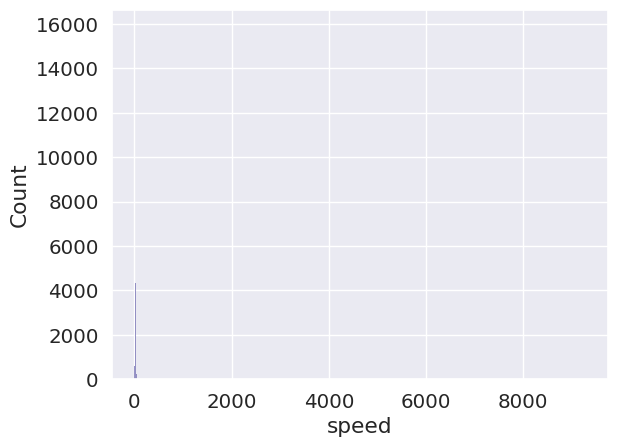

In [1291]:
sns.histplot(df['speed'])
plt.show()

Нужно аккуратно, потому что тут содержится информация о таргете

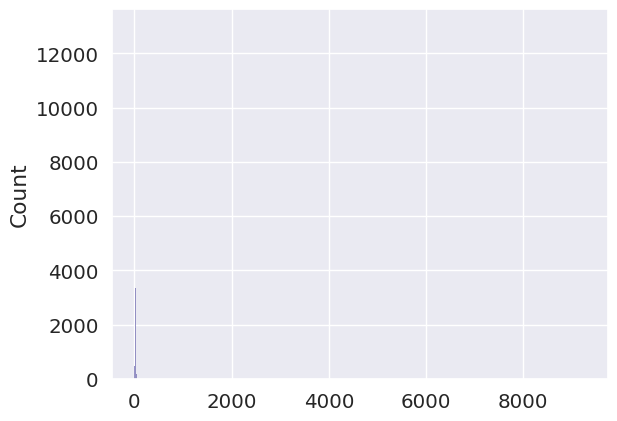

In [1292]:
speed = X_train_out['distance_km'] / (y_train_out / 60)
sns.histplot(speed)
plt.show()

In [1293]:
#Удалим по правилам пдд
mask = (speed <= 90)

X_train_clean = X_train_out[mask]
y_train_clean = y_train_out[mask]

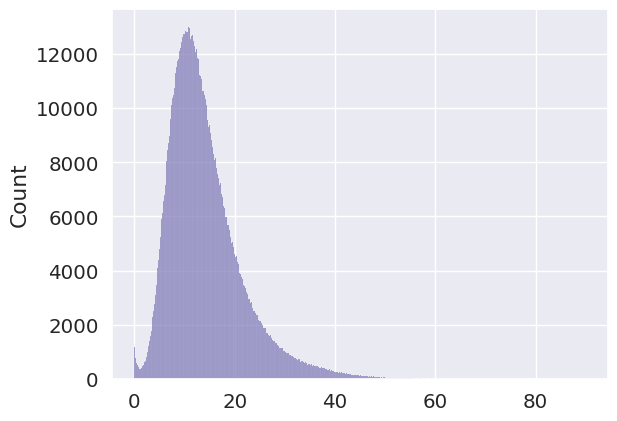

In [1294]:
sns.histplot(speed[mask])
plt.show()

**3.** **Обработка признаков на основе данных**


Выполните необходимые преобразования категориальных признаков

In [1295]:
X_train_clean.columns

Index(['passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'distance_km', 'weekday',
       'is_weekend', 'hour', 'is_peak', 'dist_peak', 'dist_weekend', 'dist2',
       'log_dist', 'month', 'day'],
      dtype='object')

In [1296]:
X_train_clean.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,weekday,is_weekend,hour,is_peak,dist_peak,dist_weekend,dist2,log_dist,month,day
1053743,1,-73.862762,40.768822,-73.891701,40.746689,3.463778,2,0,18,1,3.463778,0.000000,11.997759,1.495996,6,29
273748,1,-73.958038,40.783237,-73.975510,40.760853,2.891365,0,0,13,0,0.000000,0.000000,8.359989,1.358760,4,25
433988,1,-73.969460,40.785519,-73.989243,40.771748,2.262636,5,1,12,0,0.000000,2.262636,5.119523,1.182536,5,7
1442481,1,-73.981743,40.736549,-73.998352,40.726440,1.795030,5,1,18,1,1.795030,1.795030,3.222131,1.027843,5,14
1025834,1,-73.977913,40.752609,-73.975647,40.733139,2.173389,6,1,22,0,0.000000,2.173389,4.723619,1.154800,4,10


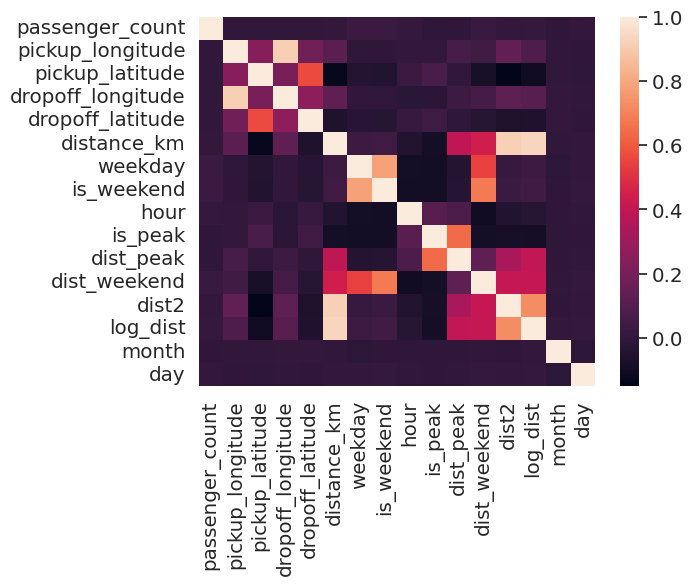

In [1297]:
sns.heatmap(X_train_clean.corr())
plt.show()

In [1298]:
# X_test = X_test0
# X_train_clean = X_train_out[mask]
# y_train_clean = y_train_out[mask]
X_train_clean = X_train_clean.drop(['month', 'day', 'dist2', 'weekday', 'dist_weekend', 'dist_peak'], axis=1)
X_test = X_test.drop(['month', 'day', 'dist2', 'weekday', 'dist_weekend', 'dist_peak'], axis=1)

cat_cols = ['passenger_count', 'is_weekend', 'is_peak', 'hour']
num_cols = [c for c in X_train_clean.columns if c not in cat_cols]

X_train_clean.loc[:, cat_cols] = X_train_clean[cat_cols].astype('category')
X_test.loc[:, cat_cols] = X_test[cat_cols].astype('category')

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

X_train_ohe = ohe.fit_transform(X_train_clean[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

X_train_ohe = pd.DataFrame(data=X_train_ohe, columns=ohe.get_feature_names_out(), index=X_train_clean.index)
X_test_ohe = pd.DataFrame(data=X_test_ohe, columns=ohe.get_feature_names_out(), index=X_test.index)

X_train = pd.concat([X_train_clean[num_cols], X_train_ohe], axis=1)
X_test = pd.concat([X_test[num_cols], X_test_ohe], axis=1)

train = pd.concat([X_train, y_train], axis=1)
test = X_test

На основе проведенного исследования данных или дополнительного анализа некоторых признаков при желании вы можете построить еще какие-либо преобразования признаков. Эту часть можно пропустить если далее получится хорошее качество модели.

**4.** **Анализ линейной регрессии**

Обучите линейную регрессию без регуляризации и посчитайте качество по метрике $R^2$, а также ошибки $RMSE, MAE, MAPE$ на тестовой выборке. При качественном препроцессинге можно получить $MAPE \sim 30\%-35\%$, но в данной задаче будет достаточно $MAPE < 45\%$.

In [1299]:
formula = 'trip_duration_min' + ' ~ ' + ' + '.join(X_train.columns)
linear = smf.ols(formula, data=train)
lm_result = linear.fit(cov_type='HC3')

In [1300]:
y_pred = lm_result.predict(test)
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred):.2f}')

MAPE: 0.43


*Прежде чем дальше выполнять домашку, убедись, что ты внимательно изучил все материалы с занятия. Там могут быть ответы на многие твои вопросы. Если все же чего-то не нашлось, спроси в чате.*

Визуализируйте зависимость остатков регрессии от нескольких признаков, примеры посмотрите в презентации и в ноутбуке с семинара. Наблюдается ли гетероскедастичность остатков?

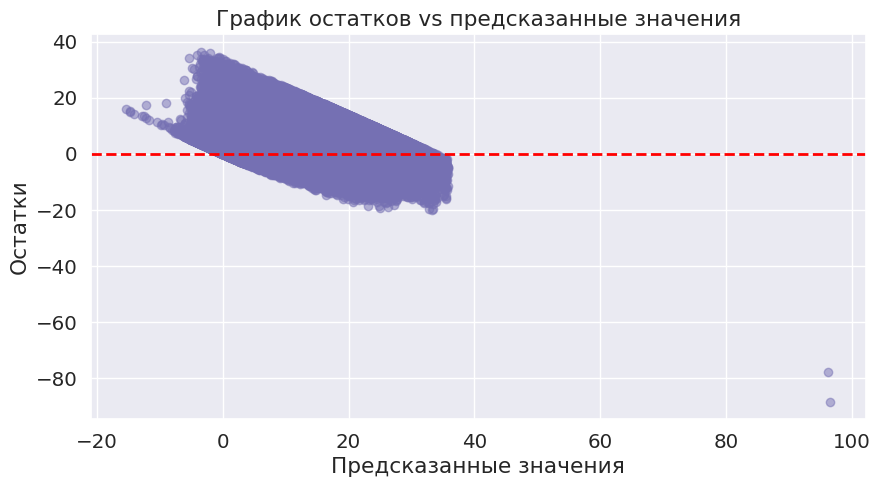

In [1301]:
residuals = lm_result.resid
fitted = lm_result.fittedvalues
plt.figure(figsize=(10, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--", lw=2)
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков vs предсказанные значения")
plt.show()

Да

Скорее всего вы ответите «да» на предыдущий вопрос. 

Тем не менее, на практике для статистического анализа модели всегда **рекомендуется всегда использовать оценки дисперсии, устойчивые к гетероскедастичности**. Их применение корректно даже в случае гомоскедастичности, соответственно, используя всегда устойчивые оценки мы повышаем надежность модели. 

В данном случае гетероскедастичность вполне ожидаема. Чем больше расстояние поездки, тем больше разброс в длительности из-за множества случайных факторов, которые невозможно предсказать заранее. Поэтому для дальнейших экспериментов обучайте модель, указывая один из типов оценок дисперсии, устойчивых к гетероскедастичности.


Оцените по графику остатков, имеется ли нелинейность по каким-то признакам? Если есть, попробуйте исправить модель. Возможны два случая:
* добавление нелинейного признака,
* монотонное преобразование таргета.

Во втором случае для всех предсказаний и интервалов, которые вы далее будете строить, необходимо сначала построить для преобразованного таргета, а затем выполнить обратное преобразование.

Для новой модели аналогично оцените качество и посмотрите на график остатков.

In [1302]:
train['log_trip_duration'] = np.log1p(y_train)
formula = 'log_trip_duration ~ ' + ' + '.join(X_train.columns)
train.drop(['trip_duration_min'], axis=1)
linear = smf.ols(formula, data=train)
lm_result = linear.fit(cov_type='HC3')

In [1303]:
y_pred = np.expm1(lm_result.predict(test))
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred):.2f}')

MAPE: 0.85


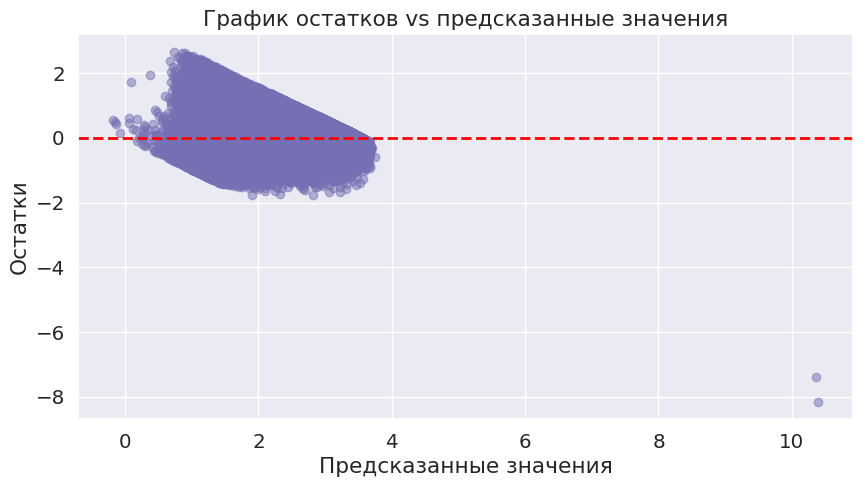

In [1304]:
residuals = lm_result.resid
fitted = lm_result.fittedvalues
plt.figure(figsize=(10, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--", lw=2)
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков vs предсказанные значения")
plt.show()

При логарифмировании таргета остатки стали более равномерно распрделены относительно нуля, гетероскедастично

Посмотрите на summary модели. Какие признаки не оказывают статистически значимого влияния на время поездки? Проверьте, что вы уже используете оценки дисперсии, устойчивые к гетероскедастичности.

In [1305]:
print(lm_result.summary())

                            OLS Regression Results                            
Dep. Variable:      log_trip_duration   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                 5.132e+04
Date:                Fri, 07 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:36:33   Log-Likelihood:            -4.1960e+05
No. Observations:             1093654   AIC:                         8.393e+05
Df Residuals:                 1093616   BIC:                         8.397e+05
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            71.8263     15.76

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 38, but rank is 37
  warnings.warn('covariance of constraints does not have full '


Насколько меняется среднее время поездки при увеличении маршрута на 1 километр? Приведите оценку и доверительный интервал. Если ранее выполнили преобразование таргета, не забудьте выполнить обратное преобразование.

Значение коэффициента: -0.1954, доверительный интервал для коэффициента: (-0.213; -0.178) - см. таблицу. Эти значения - то, насколько меняется преобразованный таргет (log1p('target')) при изменении дистанции на 1 км. Значит сам таргет меняется на:

In [1306]:
print(f'Время в пути меняется на {np.expm1(-0.1000) * 60:.2f} с при изменении расстояния на 1 км')
print(f'Доверительный интервал для изменения: ({np.expm1(-0.107) * 60:.2f}; {np.expm1(-0.093) * 60:.2f}) c')

Время в пути меняется на -5.71 с при изменении расстояния на 1 км
Доверительный интервал для изменения: (-6.09; -5.33) c


Получается как-то странно, потому что выходит, что скорость при таких показателях должны быть слишком большой. Видимо, модель занижает предсказания, ориентриуясь только на расстояния, нарпимер потому, что как видно из scatterplot выше, существует множество точек с нулевым временем, но с растущим расстоянием

**5.** **Доверительные и предсказательные интервалы**

Наша следующая цель &mdash; построить *доверительные* интервалы для *среднего* времени поездки и *предсказательные* интервалы для *фактического* времени поездки.

Сначала построим наглядные графики зависимости интервалов от одного признака &mdash; расстояние поездки. Для этого зафиксируйте значения всех остальных признаков (средним или медианой) и создайте сетку значений для расстояния. Например, от 0 до 15 км с шагом в 50-100 метров.

*Замечание.* Если вы использовали производные признаки от расстояния (например, квадрат расстояния), то такие признаки тоже нужно пересчитать по сетке.

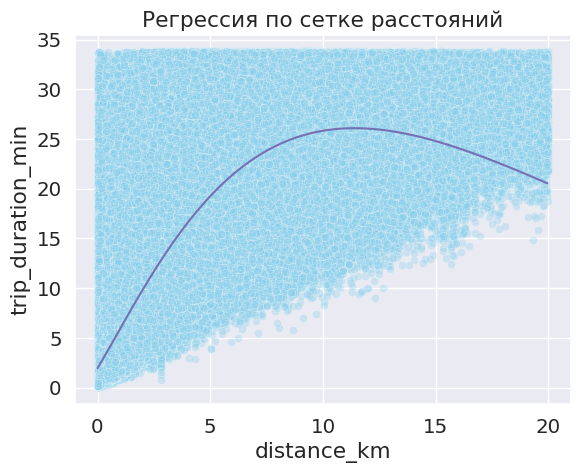

In [1307]:
grid = np.arange(0, 20, 0.05)
n = len(grid)
train_grid = pd.DataFrame(train[:n])
for column in test.columns:
    train_grid.loc[:, column] = np.mean(train[column], axis=0)
train_grid['distance_km'] = grid
train_grid['log_dist'] = np.log1p(grid)
y_pred = lm_result.predict(train_grid)
plt.plot(grid, np.expm1(y_pred))
sns.scatterplot(x=train['distance_km'], y=y_train, alpha=0.3, color='skyblue')
plt.title('Регрессия по сетке расстояний')
plt.xlabel('distance_km')
plt.ylabel('trip_duration_min')
plt.show()

Постройте *доверительные* интервалы для созданной выше сетки и визуализируйте их.

In [1308]:
pred_summary = lm_result.get_prediction(train_grid).summary_frame(alpha=0.05)
pred_summary.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,1.083609,0.001898,1.079888,1.087329,0.387542,1.779675
1,1.145646,0.001762,1.142192,1.149100,0.449580,1.841712
2,1.204537,0.001639,1.201324,1.207749,0.508472,1.900601
3,1.260561,0.001528,1.257566,1.263556,0.564498,1.956624
4,1.313962,0.001428,1.311163,1.316762,0.617900,2.010025


/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


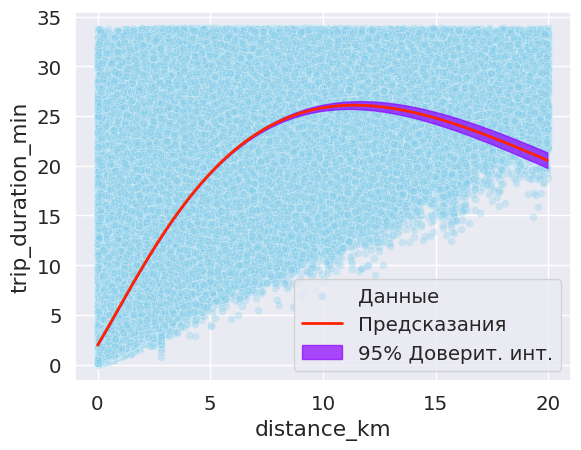

In [1309]:
sns.scatterplot(x=train["distance_km"], y=y_train, alpha=0.3, color='skyblue', label='Данные')

# Линия регрессии
plt.plot(
    grid,
    np.expm1(pred_summary["mean"]),
    color="#ff2400",
    linewidth=2,
    label="Предсказания",
)

# Доверительный интервал
plt.fill_between(
    grid,
    np.expm1(pred_summary["mean_ci_lower"]),
    np.expm1(pred_summary["mean_ci_upper"]),
    color="#8b00ff",
    alpha=0.7,
    label="95% Доверит. инт.",
)

plt.legend()
plt.show()

На занятии мы обсудили, что для построения предсказательных интервалов нужно оценить зависимость дисперсии шума от признаков. Один из способов это сделать — построить еще одну регрессионную модель для предсказания квадрата остатка основной модели.

Создайте такую модель и оцените её качество. Не забудьте, что предсказания квадрата остатка не могут быть отрицательными.

In [1310]:
def calculate_predictive_interval(
    lm_results: RegressionResultsWrapper,
    variance_model: RegressorMixin,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> pd.DataFrame:
    """Рассчитывает гетероскедастичный предиктивный интервал для регрессионной модели,
    который учитывает непостоянную дисперсию ошибок (гетероскедастичность).

    Args:
        lm_results: Результаты обученной основной регрессионной модели из `statsmodels`.
        variance_model: Экземпляр НЕОБУЧЕННОЙ регрессионной модели из scikit-learn
            для моделирования дисперсии.
        X_train (pd.DataFrame): Данные (признаки), на которых была обучена
            основная модель `lm_results`. Используются для обучения `variance_model`.
        X_test (pd.DataFrame): Данные (признаки), для которых необходимо построить
            предиктивный интервал.

    Returns:
        pd.DataFrame: DataFrame, аналогичный выводу `.summary_frame()`, но с
            добавленными колонками `obs_ci_lower_het` и `obs_ci_upper_het`,
            содержащими границы гетероскедастичного предиктивного интервала.
    """

    # Таргет вспомогательной модели - квадраты остатков
    resid2 = lm_results.resid**2

    # Обучаем регрессию: resid^2 ~ X_train
    variance_model.fit(X_train, resid2)

    # Получаем стандартные предсказания от statsmodels для X_test
    pred_summary = lm_results.get_prediction(X_test).summary_frame(alpha=0.05)

    # Предсказываем дисперсию ошибки sigma^2(x) для X_test
    sigma2_pred = variance_model.predict(X_test)

    # Убедимся, что предсказанная дисперсия не отрицательна
    sigma2_pred = np.clip(sigma2_pred, a_min=0, a_max=None)

    # Извлекаем дисперсию среднего предсказания, это и есть x_0^T * D(theta_hat) * x_0
    var_mean_pred = pred_summary["mean_se"] ** 2

    # Считаем полную дисперсию предсказания
    total_pred_variance = var_mean_pred + sigma2_pred
    total_pred_se = np.sqrt(total_pred_variance)

    # Находим квантиль t-распределения
    alpha = 0.05
    degrees_freedom = lm_results.df_resid
    t_crit = sps.t.ppf(1 - alpha / 2, df=degrees_freedom)

    # Вычисляем границы нового интервала
    margin_of_error = t_crit * total_pred_se
    pred_summary["obs_ci_lower_het"] = pred_summary["mean"] - margin_of_error
    pred_summary["obs_ci_upper_het"] = pred_summary["mean"] + margin_of_error

    return pred_summary

In [1312]:
pred_summary = calculate_predictive_interval(
    lm_result, HuberRegressor(), X_train, train_grid.drop(['trip_duration_min',	'log_trip_duration'], axis=1)
)
pred_summary.head()

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,obs_ci_lower_het,obs_ci_upper_het
0,1.083609,0.001898,1.079888,1.087329,0.387542,1.779675,0.426471,1.740747
1,1.145646,0.001762,1.142192,1.149100,0.449580,1.841712,0.495129,1.796163
2,1.204537,0.001639,1.201324,1.207749,0.508472,1.900601,0.560355,1.848719
3,1.260561,0.001528,1.257566,1.263556,0.564498,1.956624,0.622451,1.898671
4,1.313962,0.001428,1.311163,1.316762,0.617900,2.010025,0.681681,1.946244


Теперь все готово для построения предсказательного интервала. Постройте его и визуализируйте.

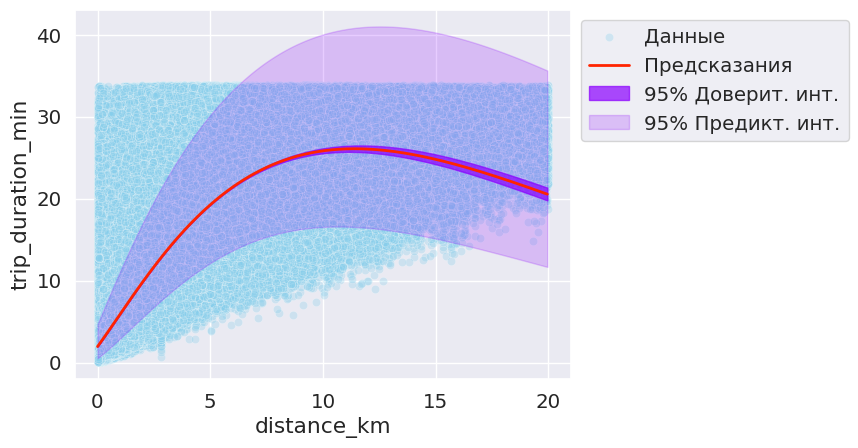

In [1313]:
sns.scatterplot(x=train["distance_km"], y=y_train, alpha=0.3, color='skyblue', label='Данные')

# Линия регрессии
plt.plot(
    grid,
    np.expm1(pred_summary["mean"]),
    color="#ff2400",
    linewidth=2,
    label="Предсказания",
)

# Доверительный интервал
plt.fill_between(
    grid,
    np.expm1(pred_summary["mean_ci_lower"]),
    np.expm1(pred_summary["mean_ci_upper"]),
    color="#8b00ff",
    alpha=0.7,
    label="95% Доверит. инт.",
)

lower_col, upper_col = ("obs_ci_lower_het", "obs_ci_upper_het")
plt.fill_between(
    grid,
    np.expm1(pred_summary[lower_col]),
    np.expm1(pred_summary[upper_col]),
    color="#8b00ff",
    alpha=0.2,
    label="95% Предикт. инт.",
)

plt.legend(bbox_to_anchor=(1, 1))
plt.show()

Выберите случайных 50-100 поездок из тестовой выборки и постройте для них оба вида интервала — доверительный и предсказательный. Визуализируйте эти интервалы на графике (может помочь `plt.errorbar`).

In [1315]:
ind = np.random.choice(test.index, 100)
X_test_sub = X_test.loc[ind, :]
y_test_sub = y_test.loc[ind]

pred_summary = calculate_predictive_interval(
    lm_result, HuberRegressor(), X_train, X_test_sub
)
pred_summary.head()

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,obs_ci_lower_het,obs_ci_upper_het
0,3.528196,0.005786,3.516854,3.539537,2.832046,4.224345,3.056959,3.999433
1,1.373662,0.003886,1.366045,1.381279,0.677563,2.069761,0.730575,2.016749
2,1.967473,0.004828,1.958010,1.976936,1.271352,2.663595,1.375326,2.559621
3,2.596449,0.001961,2.592605,2.600293,1.900382,3.292517,2.148897,3.044001
4,3.305911,0.009122,3.288032,3.323791,2.609625,4.002198,2.878761,3.733061


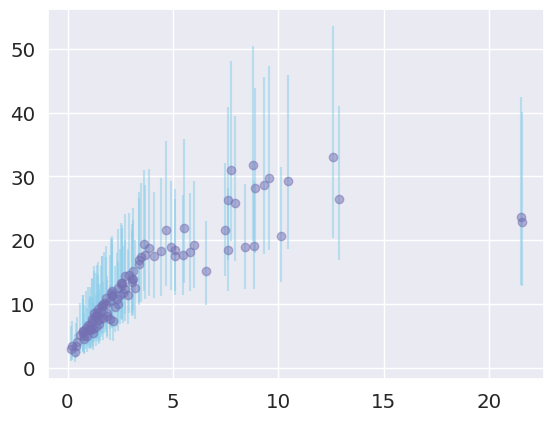

In [1316]:
y_mean = np.expm1(pred_summary['mean'])
y_lower = np.expm1(pred_summary['obs_ci_lower_het'])
y_upper = np.expm1(pred_summary['obs_ci_upper_het'])

yerr = (y_mean - y_lower, y_upper - y_mean)

plt.errorbar(x=X_test_sub['distance_km'], y=y_mean, 
             yerr=yerr, 
             ecolor='skyblue', fmt='o', alpha=0.5)
plt.show()

Какие выводы можно сделать про эти два вида интервалов?

Предсказательный интервал — это инструмент для интерпретации конкретного прогноза, оценки неопределённости и проверки адекватности модели на уровне отдельных наблюдений, а не только коэффициентов регрессии.

Важно отметить, что предсказательный интервал не улучшает само предсказание, но позволяет интерпретировать его более осторожно и реалистично, предотвращая иллюзию чрезмерной уверенности.

Наконец, оценим, насколько корректно мы построили предсказательные интервалы. Оцените долю покрытия предсказательным интервалом *фактического* времени поездки по *всем* точкам тестовой выборки.

In [1318]:
pred_summary = calculate_predictive_interval(
    lm_result, HuberRegressor(), X_train, X_test
)
pred_summary.head()

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,obs_ci_lower_het,obs_ci_upper_het
0,2.519954,0.001895,2.516241,2.523667,1.823887,3.216021,2.059462,2.980446
1,2.417750,0.001894,2.414038,2.421462,1.721683,3.113817,1.881914,2.953586
2,1.886271,0.002730,1.880921,1.891622,1.190194,2.582349,1.364818,2.407725
3,2.526976,0.002369,2.522333,2.531620,1.830904,3.223049,2.013904,3.040049
4,3.191305,0.005048,3.181411,3.201198,2.495177,3.887432,2.643137,3.739472


In [1319]:
lower = np.expm1(pred_summary['obs_ci_lower_het'].values)
upper = np.expm1(pred_summary['obs_ci_upper_het'].values)
print('Реальный уровенье доверия предсказательного интервала:', ((y_test >= lower) * (y_test <= upper)).mean())

Реальный уровенье доверия предсказательного интервала: 0.8279087783525121


**Общие выводы по задаче**

## Анализ и улучшение линейной регрессии

### 1. Корректность доверительных интервалов
Предсказательный интервал, рассчитанный при стандартных предположениях, часто даёт **заниженный реальный уровень значимости**.  
Чтобы получить более надёжные результаты, рекомендуется использовать **оценки, устойчивые к гетероскедастичности** (например, `HC3`).

---

### 2. Преобразования таргета
Для повышения качества модели полезно применять **монотонные преобразования таргета** — например, `log1p`, `sqrt` или `Box–Cox`.  
Такие преобразования позволяют:
- стабилизировать дисперсию;
- сделать распределение ближе к нормальному;

---

### 3. Инженерия признаков и выбросы
Хороший результат достигается не только за счёт формальных методов, но и благодаря **интуитивным шагам**:
- удаление выбросов «на глаз», если они явно искажают структуру данных;
- внимательная работа с признаками — иногда удаление даже одного «лишнего» ухудшает качество.

---

### 4. Корреляции между признаками
Для линейной регрессии критически важен **анализ матрицы корреляций**:
- сильная корреляция (мультиколлинеарность) между признаками ухудшает устойчивость модели;
- однако, **удаление скоррелированных признаков** может привести к **потере информации** и ухудшению предсказаний.  
Здесь важно найти баланс между интерпретируемостью и точностью.

---

### 5. Использование `statsmodels`
Библиотека `statsmodels` позволяет быстро получать:
- параметры модели и их доверительные интервалы;
- статистически обоснованные метрики (t-тесты, F-тесты);
- поправки на гетероскедастичность.

Перед расчётом результатов полезно проанализировать **остатки** — проверить их распределение, автокорреляцию и наличие выбросов.

---

### Вывод
Линейная регрессия остаётся мощным и интерпретируемым инструментом, если:
- учитывать статистические допущения;
- грамотно работать с признаками и таргетом;
- проверять поведение остатков;
- не бояться отходить от «шаблона», если это повышает качество и устойчивость модели.


<b><font color="red" size="5">Задачи будут добавлены</font></b>


---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока